### Astrostatistics lecure 5

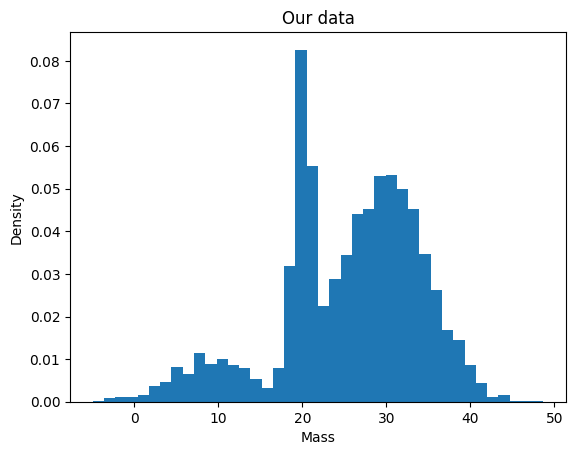

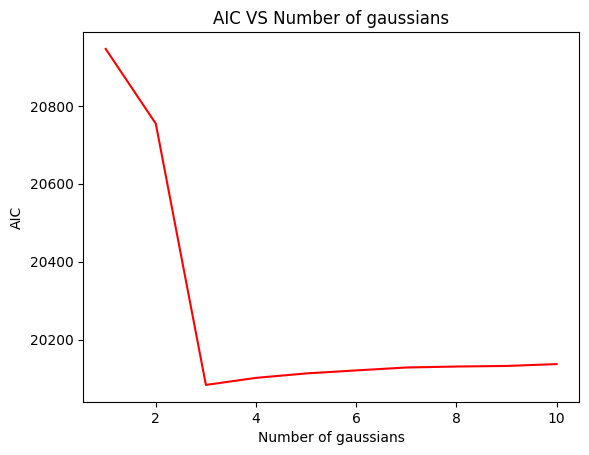

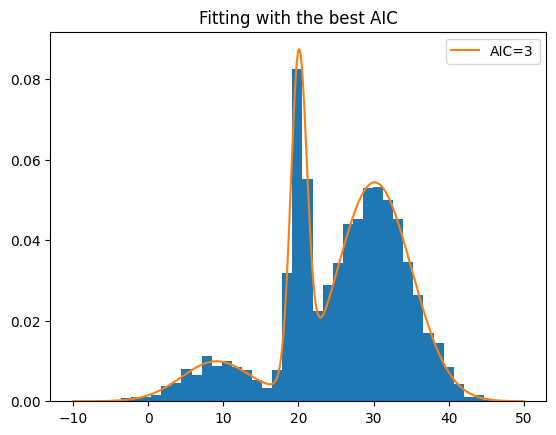

In [48]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.mixture import GaussianMixture

data = np.load("/home/ricca/astrostat/astrostatistics_bicocca_2026/solutions/formationchannels.npy")

plt.title('Our data')
plt.hist(data, bins=40, density=True)
plt.ylabel('Density')
plt.xlabel('Mass')
plt.show()
AIC=[]
num=[]

for i in range(10):
    gauss_mix = GaussianMixture(n_components=i+1, random_state=42).fit(data) #mixture of 10 gaussians 
    AIC.append(gauss_mix.aic(data))
    num.append(i+1)
index=np.argmin(AIC)+1

plt.plot(num, AIC, color='red')
plt.ylabel('AIC')
plt.xlabel('Number of gaussians')
plt.title('AIC VS Number of gaussians')
plt.show()

#fit with the best data 
best_mix = GaussianMixture(n_components=index, random_state=42).fit(data)
x=np.linspace(-10, 50, 5000).reshape(-1,1)
log_likeli = best_mix.score_samples(x)
likeli = np.exp (log_likeli)

plt.hist(data, bins=40, density=True)
plt.title('Fitting with the best AIC')
plt.plot(x, likeli, label=f'AIC={index}')
plt.legend()
plt.show()
